<a href="https://colab.research.google.com/github/shinjeongdong/MLDeeplearningStudy/blob/main/%5BPyTorch%5D/%5BPyTorch%5D_5_3_CIFAR_10%2C_MLP_vs_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#주요 함수를 모듈화 해서 가독성을살리고  코드를 줄임
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/func/')
from multiclass_functions1 import *

DEVICE = 'cuda' if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [2]:
from torch.optim import optimizer
BATCH_SIZE = 32 #배치 사이즈
LR = 6e-3 #Lr = 0.006
EPOCH = 40 #에폭 40
criterion = nn.CrossEntropyLoss() #CE

new_model_train = False #train 여부
model_type = 'CNN_deep'
dataset1 = "CIFAR10"
save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}.pt" #웨이트 저장경로

In [3]:
transform = transforms.ToTensor() #ToTensor데이터
train_DS = datasets.CIFAR10(root = "/content/drive/MyDrive/Colab Notebooks", train=True, download= True, transform=transform)
test_DS = datasets.CIFAR10(root = "/content/drive/MyDrive/Colab Notebooks", train=False, download= True, transform=transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size = BATCH_SIZE, shuffle = True) # 32개 무작위
test_DL = torch.utils.data.DataLoader(test_DS, batch_size = BATCH_SIZE, shuffle = True) # 32개 무작위

In [4]:
print(train_DS) # 50000,32,32,3
print(test_DS)# 10000,32,32,3

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /content/drive/MyDrive/Colab Notebooks
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /content/drive/MyDrive/Colab Notebooks
    Split: Test
    StandardTransform
Transform: ToTensor()


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
torch.Size([32, 3, 32, 32])
ship


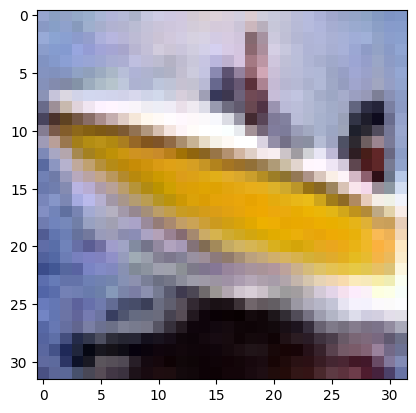

In [5]:
print(test_DS.classes)
print(test_DS.class_to_idx)
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape) #(32,3,32,32)
plt.imshow(x_batch[0].permute(1,2,0)) #imshow를 할땐 행x열x채 형태로 되야함 32x32x3
print(test_DS.classes[y_batch[0]])

In [6]:
x_batch, y_batch = next(iter(train_DL)) # 데이터 한 국자 32개 이미지, 32레이블
#ToTensor 역할
# 1. tensor로 바꿈
# 2. 개채행렬로 바꾸고 28x28 -> 1x28x28 행렬 -> 채널x행x열
# 3. 0~1 사이로 바꿈 (int -> float)
print(type(train_DS.data))  # numpy.ndarray
print(train_DS.data.shape) # 50000,32,32,3
print(train_DS.data.dtype) # uint8 정수형
print(train_DS.data[0][0][0][0])

print("-"*20)

print(type(x_batch)) # torch.Tensor
print(x_batch.shape) # (32,3,28,28)
print(x_batch.dtype) # float
print(x_batch[0][0][0][0])



<class 'numpy.ndarray'>
(50000, 32, 32, 3)
uint8
59
--------------------
<class 'torch.Tensor'>
torch.Size([32, 3, 32, 32])
torch.float32
tensor(0.9451)


In [7]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fcs = nn.Sequential(nn.Linear(3*32*32, 30),
                             nn.BatchNorm1d(30),
                             nn.ReLU(),
                             nn.Linear(30,10)) #짜피 로스를 ce로 잡으면 자동으로 소프트맥스가 됨

  def forward(self,x):
    x = torch.flatten(x,start_dim = 1)
    x = self.fcs(x)
    return x

class MLP_shallow(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Sequential(nn.Linear(3*32*32, 100),
                             nn.BatchNorm1d(100),
                             nn.ReLU(),
                             nn.Linear(100,10))
  def forward(self,x):
    x = torch.flatten(x,start_dim = 1)
    x = self.fcs(x)
    return x

class MLP_deep(nn.Module):
  def __init__(self):
    super().__init__()
    self.fcs = nn.Sequential(nn.Linear(3*32*32, 75),
                             nn.BatchNorm1d(75),
                             nn.ReLU(),
                             *[i for _ in range(4) for i in [nn.Linear(75,75), nn.ReLU()]],
                             nn.Linear(75,10))

  def forward(self,x):
    x = torch.flatten(x,start_dim = 1)
    x = self.fcs(x)
    return x


class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Sequential(nn.Conv2d(3,8,3, padding = 1),
                               nn.BatchNorm2d(8),
                               nn.ReLU())

    self.Maxpool1 = nn.MaxPool2d(2)
    self.conv2 = nn.Sequential(nn.Conv2d(8,16,3, padding = 1),
                               nn.BatchNorm2d(16),
                               nn.ReLU())

    self.Maxpool2 = nn.MaxPool2d(2)
    self.conv3 = nn.Sequential(nn.Conv2d(16,32,3, padding = 1),
                               nn.BatchNorm2d(32),
                               nn.ReLU())

    self.Maxpool3 = nn.MaxPool2d(2)
    self.fc = nn.Linear(32*4*4,10)

  def forward(self,x):
    x = self.conv1(x)
    x = self.Maxpool1(x)
    x = self.conv2(x)
    x = self.Maxpool2(x)
    x = self.conv3(x)
    x = self.Maxpool3(x)
    x = torch.flatten(x, start_dim = 1)
    x = self.fc(x)
    return x


class CNN_deep(nn.Module):
  def __init__(self):
    super().__init__()
    #conv2d = RGB, 출력 특징맵, 커널 사이즈, 패딩 => 1일때 좌우 위아래에 0짜리 추가됨 크기유지하기 위해
    self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3, padding = 1),
                                    nn.BatchNorm2d(32),
                                    nn.ReLU(),
                                    nn.Conv2d(32,32,3,padding=1),
                                    nn.BatchNorm2d(32),
                                    nn.ReLU())

    self.Maxpool1 = nn.MaxPool2d(2)
    self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3, padding = 1),
                                     nn.BatchNorm2d(64),
                                     nn.ReLU(),
                                     nn.Conv2d(64,64,3,padding=1),
                                     nn.BatchNorm2d(64),
                                     nn.ReLU(),
                                     nn.Conv2d(64,64,3,padding = 1),
                                     nn.BatchNorm2d(64),
                                     nn.ReLU())

    self.Maxpool2 = nn.MaxPool2d(2)
    self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3, padding = 1),
                                     nn.BatchNorm2d(128),
                                     nn.ReLU(),
                                     nn.Conv2d(128,128,3,padding=1),
                                     nn.BatchNorm2d(128),
                                     nn.ReLU(),
                                     nn.Conv2d(128,128,3,padding = 1),
                                     nn.BatchNorm2d(128),
                                     nn.ReLU())


    self.Maxpool3 = nn.MaxPool2d(2)
    self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
                                    nn.ReLU(),
                                    nn.Linear(512,10))

  def forward(self,x):
    x = self.conv_block1(x)
    x = self.Maxpool1(x)
    x = self.conv_block2(x)
    x = self.Maxpool2(x)
    x = self.conv_block3(x)
    x = self.Maxpool3(x)
    x = torch.flatten(x, start_dim = 1)
    x = self.classifier(x)
    return x







In [8]:
if new_model_train:
  model = globals()[model_type]().to(DEVICE) #globals함수 쓰면 str의 ''가 벗겨져서 model_type변수를 찾아옴
  optimizer = optim.Adam(model.parameters(),lr = LR) # 최적화 기법 설정
  loss_history = Train(model,train_DL,criterion,optimizer,EPOCH) # 학습

  plt.plot(range(1,EPOCH + 1),loss_history)
  plt.xlabel("EPOCH")
  plt.ylabel("loss")
  plt.title("Train loss")
  plt.grid()
  torch.save(model, save_model_path)
else:
  model = torch.load(save_model_path,map_location=DEVICE,weights_only=False)


In [9]:
Test(model, test_DL)# CNN_deep = 82.0%, CNN = 70.2 %, MLP_deep = 46.8%

Test accuracy: 8203/10000 (82.0 %)


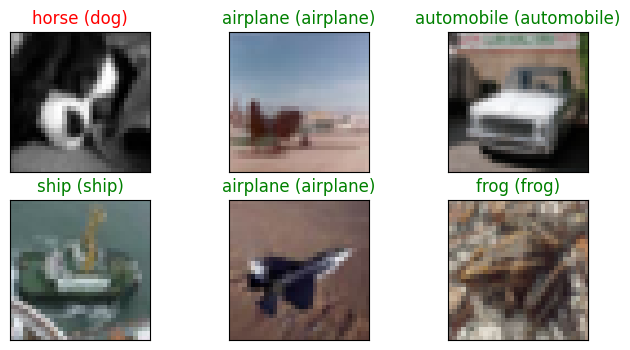

In [10]:
Test_plot(model,test_DL)

In [11]:
count_params(model)

1527018

torch.Size([1, 6, 3])